# Dysarthric Speech Detection via Late Fusion of Temporal MFCC Sequences and Prosodic Features using 1D-CNN

**Research Contribution:**  
This notebook implements a novel late-fusion architecture that addresses two key gaps in existing TORGO literature:
1. Prior work discards temporal dynamics by frame-averaging MFCCs before classification
2. No prior TORGO binary detection paper fuses temporal MFCC sequences with hand-crafted prosodic features at the representation level

**Ablation Study:** Three conditions are evaluated:
- **Baseline**: SVM on frame-averaged MFCCs (replicates prior work)
- **Model B**: 1D-CNN on temporal MFCC sequences only  
- **Model C (Proposed)**: 1D-CNN + Prosodic late fusion

**Dataset:** TORGO Database (Rudzicz et al., 2012)

## 1. Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score
)
from sklearn.pipeline import Pipeline

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU,
    GlobalAveragePooling1D, Dense, Dropout,
    Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Prosodic feature extraction
try:
    import parselmouth
    from parselmouth.praat import call
    PARSELMOUTH_AVAILABLE = True
except ImportError:
    print("parselmouth not found. Install with: pip install praat-parselmouth")
    PARSELMOUTH_AVAILABLE = False

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 13
sns.set_style('darkgrid')

print("TensorFlow version:", tf.__version__)
print("Setup complete.")

2026-03-30 16:12:01.084853: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774887121.480576      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774887121.593542      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774887122.555135      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774887122.555176      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774887122.555179      55 computation_placer.cc:177] computation placer alr

parselmouth not found. Install with: pip install praat-parselmouth
TensorFlow version: 2.19.0
Setup complete.


In [3]:
pip install praat-parselmouth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 68.1 MB/s eta 0:00:00:00:01:01
Note: you may need to restart the kernel to use updated packages.


## 2. Data Loading and EDA

In [4]:
import os
import pandas as pd

BASE_PATH = '/kaggle/input/datasets/iamhungundji/dysarthria-detection'
CSV_PATH = os.path.join(BASE_PATH, 'torgo_data/data.csv')

data = pd.read_csv(CSV_PATH)

# FIXED LINE 🔥
data['filepath'] = data['filename'].apply(
    lambda x: os.path.join(BASE_PATH, x)
)

print(f"Total samples: {len(data)}")
print("\nClass distribution:")
print(data['is_dysarthria'].value_counts())
print("\nGender distribution:")
print(data['gender'].value_counts())

data.head()

Total samples: 2000

Class distribution:
is_dysarthria
non_dysarthria    1000
dysarthria        1000
Name: count, dtype: int64

Gender distribution:
gender
female    1000
male      1000
Name: count, dtype: int64


,is_dysarthria,gender,filename,filepath
0,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...,/kaggle/input/datasets/iamhungundji/dysarthria...
1,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...,/kaggle/input/datasets/iamhungundji/dysarthria...
2,non_dysarthria,female,torgo_data/non_dysarthria_female/FC02_Session3...,/kaggle/input/datasets/iamhungundji/dysarthria...
3,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session2...,/kaggle/input/datasets/iamhungundji/dysarthria...
4,non_dysarthria,female,torgo_data/non_dysarthria_female/FC03_Session1...,/kaggle/input/datasets/iamhungundji/dysarthria...


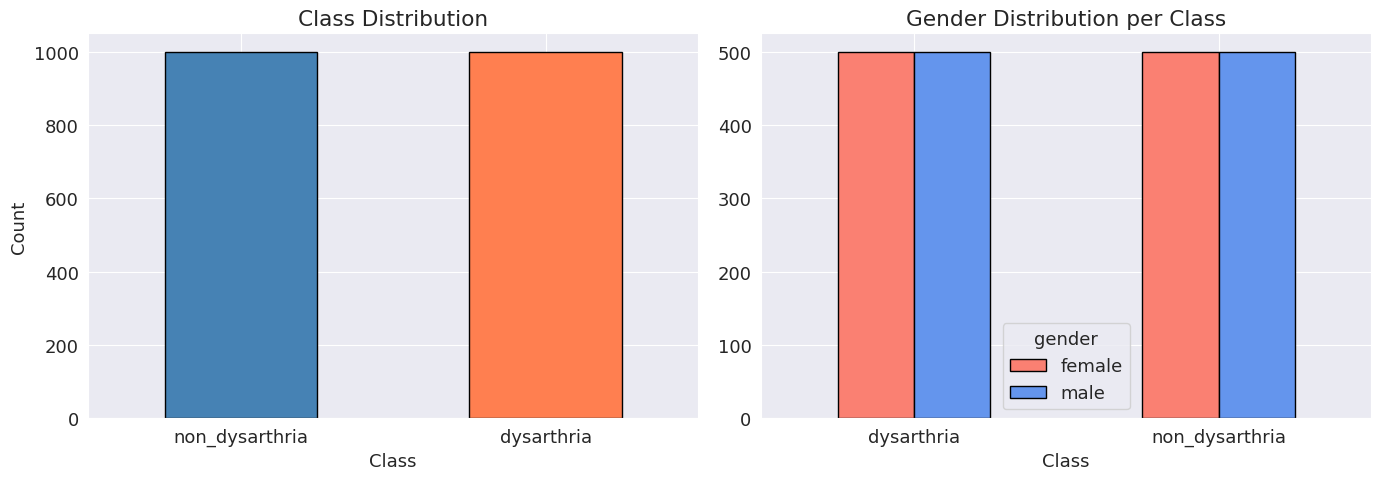

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class balance
data['is_dysarthria'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'],
    edgecolor='black'
)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Gender split per class
pd.crosstab(data['is_dysarthria'], data['gender']).plot(
    kind='bar', ax=axes[1], color=['salmon', 'cornflowerblue'],
    edgecolor='black'
)
axes[1].set_title('Gender Distribution per Class')
axes[1].set_xlabel('Class')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

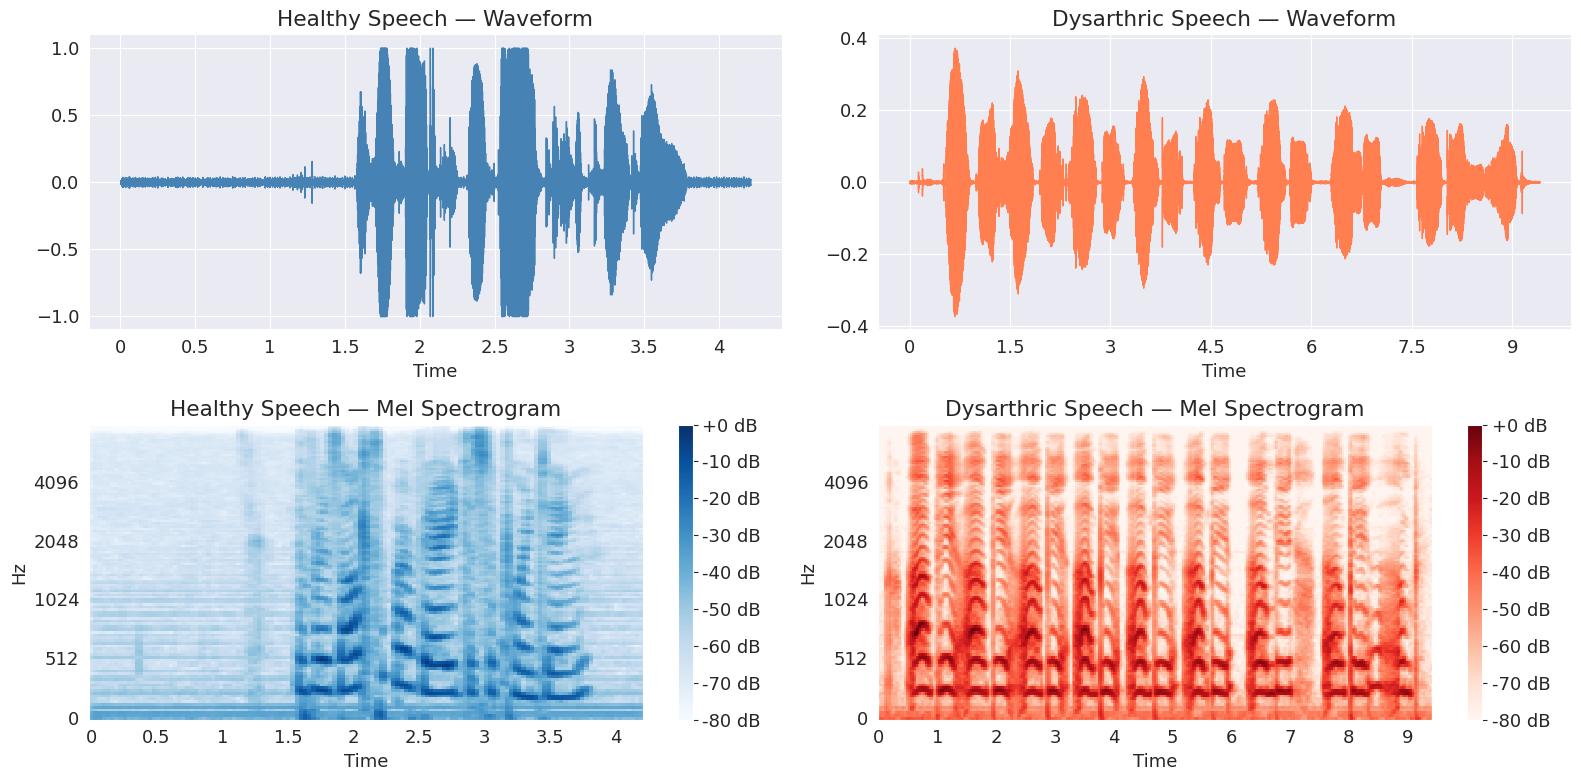

In [6]:
# Visualise one dysarthric vs one healthy waveform + spectrogram
sample_dys = data[data['is_dysarthria'] == 'dysarthria']['filepath'].iloc[0]
sample_non = data[data['is_dysarthria'] == 'non_dysarthria']['filepath'].iloc[0]

y_dys, sr = librosa.load(sample_dys, sr=16000)
y_non, sr = librosa.load(sample_non, sr=16000)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Waveforms
librosa.display.waveshow(y_non, sr=sr, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Healthy Speech — Waveform')

librosa.display.waveshow(y_dys, sr=sr, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Dysarthric Speech — Waveform')

# Mel spectrograms
for ax, y, title, cmap in zip(
    [axes[1, 0], axes[1, 1]],
    [y_non, y_dys],
    ['Healthy Speech — Mel Spectrogram', 'Dysarthric Speech — Mel Spectrogram'],
    ['Blues', 'Reds']
):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time',
                                    y_axis='mel', ax=ax, cmap=cmap)
    ax.set_title(title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.savefig('waveform_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()

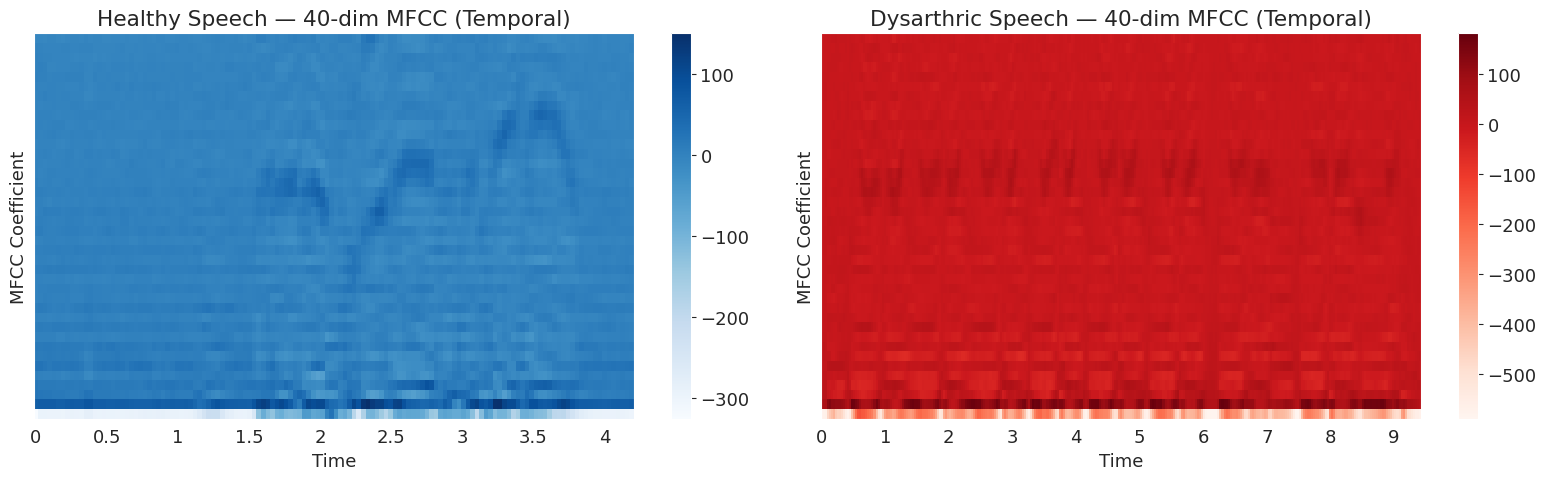

Note: Temporal MFCC shape preserved — NOT frame-averaged.
MFCC shape (n_mfcc x time_frames): (40, 132)


In [7]:
# MFCC comparison: healthy vs dysarthric
mfcc_non = librosa.feature.mfcc(y=y_non, sr=sr, n_mfcc=40)
mfcc_dys = librosa.feature.mfcc(y=y_dys, sr=sr, n_mfcc=40)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, mfcc, title, cmap in zip(
    axes,
    [mfcc_non, mfcc_dys],
    ['Healthy Speech — 40-dim MFCC (Temporal)', 'Dysarthric Speech — 40-dim MFCC (Temporal)'],
    ['Blues', 'Reds']
):
    img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=ax, cmap=cmap)
    ax.set_title(title)
    ax.set_ylabel('MFCC Coefficient')
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig('mfcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: Temporal MFCC shape preserved — NOT frame-averaged.")
print(f"MFCC shape (n_mfcc x time_frames): {mfcc_non.shape}")

## 3. Feature Extraction

### 3.1 Temporal MFCC Sequences (40-dim, T=128 frames)
Unlike prior work that averages MFCC frames into a single vector, we preserve the full temporal sequence. This captures the irregular articulation dynamics characteristic of dysarthric speech.

### 3.2 Prosodic Features (7-dim)
We extract clinically-motivated hand-crafted prosodic features: jitter, shimmer, HNR, mean F0, std F0, speaking rate, and voice break percentage.

In [8]:
# ── Configuration ──────────────────────────────────────────
N_MFCC     = 40    # MFCC dimensions (standard in literature)
MAX_FRAMES = 128   # Fixed temporal length (pad/truncate)
SR         = 16000 # Sampling rate (TORGO standard)
N_PROSODIC = 7     # Number of prosodic features
# ───────────────────────────────────────────────────────────

def extract_mfcc_sequence(filepath, n_mfcc=N_MFCC, max_frames=MAX_FRAMES, sr=SR):
    """
    Extract temporal MFCC sequence, preserving time dimension.
    Returns shape: (max_frames, n_mfcc) — input for 1D-CNN.
    """
    try:
        y, _ = librosa.load(filepath, sr=sr)
        # Pre-emphasis
        y = librosa.effects.preemphasis(y)
        # Extract MFCCs with delta and delta-delta
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                     hop_length=160, n_fft=512)
        # Transpose: (n_mfcc, T) → (T, n_mfcc)
        mfcc = mfcc.T
        # Pad or truncate to fixed length
        if mfcc.shape[0] < max_frames:
            pad = max_frames - mfcc.shape[0]
            mfcc = np.pad(mfcc, ((0, pad), (0, 0)), mode='constant')
        else:
            mfcc = mfcc[:max_frames, :]
        return mfcc.astype(np.float32)
    except Exception as e:
        return np.zeros((max_frames, n_mfcc), dtype=np.float32)


def extract_prosodic_features(filepath, sr=SR):
    """
    Extract 7 clinically-motivated prosodic features using Praat (parselmouth).
    Features: jitter, shimmer, HNR, F0 mean, F0 std, speaking rate, voice break %
    Returns shape: (7,)
    """
    features = np.zeros(N_PROSODIC, dtype=np.float32)

    if not PARSELMOUTH_AVAILABLE:
        # Fallback: librosa-based approximate prosodic features
        try:
            y, _ = librosa.load(filepath, sr=sr)
            f0, voiced_flag, _ = librosa.pyin(
                y, fmin=75, fmax=500, sr=sr
            )
            f0_valid = f0[voiced_flag > 0]
            features[0] = 0.0   # jitter placeholder
            features[1] = 0.0   # shimmer placeholder
            features[2] = 0.0   # HNR placeholder
            features[3] = float(np.nanmean(f0_valid)) if len(f0_valid) > 0 else 0.0
            features[4] = float(np.nanstd(f0_valid))  if len(f0_valid) > 0 else 0.0
            # Approximate speaking rate via zero crossing rate
            zcr = librosa.feature.zero_crossing_rate(y)
            features[5] = float(np.mean(zcr))
            features[6] = float(1.0 - np.mean(voiced_flag)) if voiced_flag is not None else 0.0
        except Exception:
            pass
        return np.nan_to_num(features)

    try:
        sound = parselmouth.Sound(filepath)

        # Jitter (local pitch perturbation)
        pp = call(sound, "To PointProcess (periodic, cc)", 75, 500)
        jitter = call(pp, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        features[0] = float(jitter) if jitter and not np.isnan(jitter) else 0.0

        # Shimmer (local amplitude perturbation)
        shimmer = call([sound, pp], "Get shimmer (local)",
                       0, 0, 0.0001, 0.02, 1.3, 1.6)
        features[1] = float(shimmer) if shimmer and not np.isnan(shimmer) else 0.0

        # Harmonics-to-Noise Ratio
        harmonicity = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)
        features[2] = float(hnr) if hnr and not np.isnan(hnr) else 0.0

        # F0 (Fundamental Frequency) — mean and std
        pitch = call(sound, "To Pitch", 0, 75, 500)
        f0_mean = call(pitch, "Get mean", 0, 0, "Hertz")
        f0_std  = call(pitch, "Get standard deviation", 0, 0, "Hertz")
        features[3] = float(f0_mean) if f0_mean and not np.isnan(f0_mean) else 0.0
        features[4] = float(f0_std)  if f0_std  and not np.isnan(f0_std)  else 0.0

        # Approximate speaking rate (syllables/sec via voiced fraction)
        total_frames = call(pitch, "Get number of frames")
        voiced_frames = call(pitch, "Count voiced frames")
        duration = call(sound, "Get total duration")
        voiced_frac = voiced_frames / total_frames if total_frames > 0 else 0.0
        features[5] = voiced_frac / duration if duration > 0 else 0.0

        # Voice break percentage
        vb_pct = call(pp, "Get fraction of locally unvoiced frames",
                      0, 0, 0.0001, 0.02, 1.3, 1.6)
        features[6] = float(vb_pct) if vb_pct and not np.isnan(vb_pct) else 0.0

    except Exception:
        pass

    return np.nan_to_num(features)


def extract_averaged_mfcc(filepath, n_mfcc=N_MFCC, sr=SR):
    """
    Baseline: frame-averaged MFCC vector (replicates prior work).
    Returns shape: (n_mfcc,)
    """
    try:
        y, _ = librosa.load(filepath, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc, axis=1).astype(np.float32)
    except Exception:
        return np.zeros(n_mfcc, dtype=np.float32)


print("Feature extraction functions defined.")
print(f"MFCC sequence shape per sample: ({MAX_FRAMES}, {N_MFCC})")
print(f"Prosodic feature vector size: {N_PROSODIC}")
print(f"Baseline averaged MFCC size: {N_MFCC}")

Feature extraction functions defined.
MFCC sequence shape per sample: (128, 40)
Prosodic feature vector size: 7
Baseline averaged MFCC size: 40


In [9]:
# ── Run feature extraction over entire dataset ──
# This may take several minutes depending on dataset size

filepaths = data['filepath'].tolist()
labels_raw = data['is_dysarthria'].tolist()

print(f"Extracting features for {len(filepaths)} audio files...")

X_mfcc_seq  = []   # Temporal MFCC sequences — for 1D-CNN
X_prosodic  = []   # Prosodic feature vectors — for fusion branch
X_mfcc_avg  = []   # Averaged MFCCs — for SVM baseline
y_labels    = []

for fp, lab in tqdm(zip(filepaths, labels_raw), total=len(filepaths)):
    if not os.path.exists(fp):
        continue
    X_mfcc_seq.append(extract_mfcc_sequence(fp))
    X_prosodic.append(extract_prosodic_features(fp))
    X_mfcc_avg.append(extract_averaged_mfcc(fp))
    y_labels.append(1 if lab == 'dysarthria' else 0)

X_mfcc_seq = np.array(X_mfcc_seq, dtype=np.float32)  # (N, 128, 40)
X_prosodic  = np.array(X_prosodic, dtype=np.float32)  # (N, 7)
X_mfcc_avg  = np.array(X_mfcc_avg, dtype=np.float32)  # (N, 40)
y           = np.array(y_labels, dtype=np.int32)        # (N,)

print(f"\nExtraction complete.")
print(f"MFCC sequence array: {X_mfcc_seq.shape}")
print(f"Prosodic array:      {X_prosodic.shape}")
print(f"Averaged MFCC array: {X_mfcc_avg.shape}")
print(f"Labels array:        {y.shape}  | Dysarthric: {y.sum()} | Healthy: {(y==0).sum()}")

Extracting features for 2000 audio files...


100%|██████████| 2000/2000 [07:49<00:00,  4.26it/s]


Extraction complete.
MFCC sequence array: (2000, 128, 40)
Prosodic array:      (2000, 7)
Averaged MFCC array: (2000, 40)
Labels array:        (2000,)  | Dysarthric: 1000 | Healthy: 1000


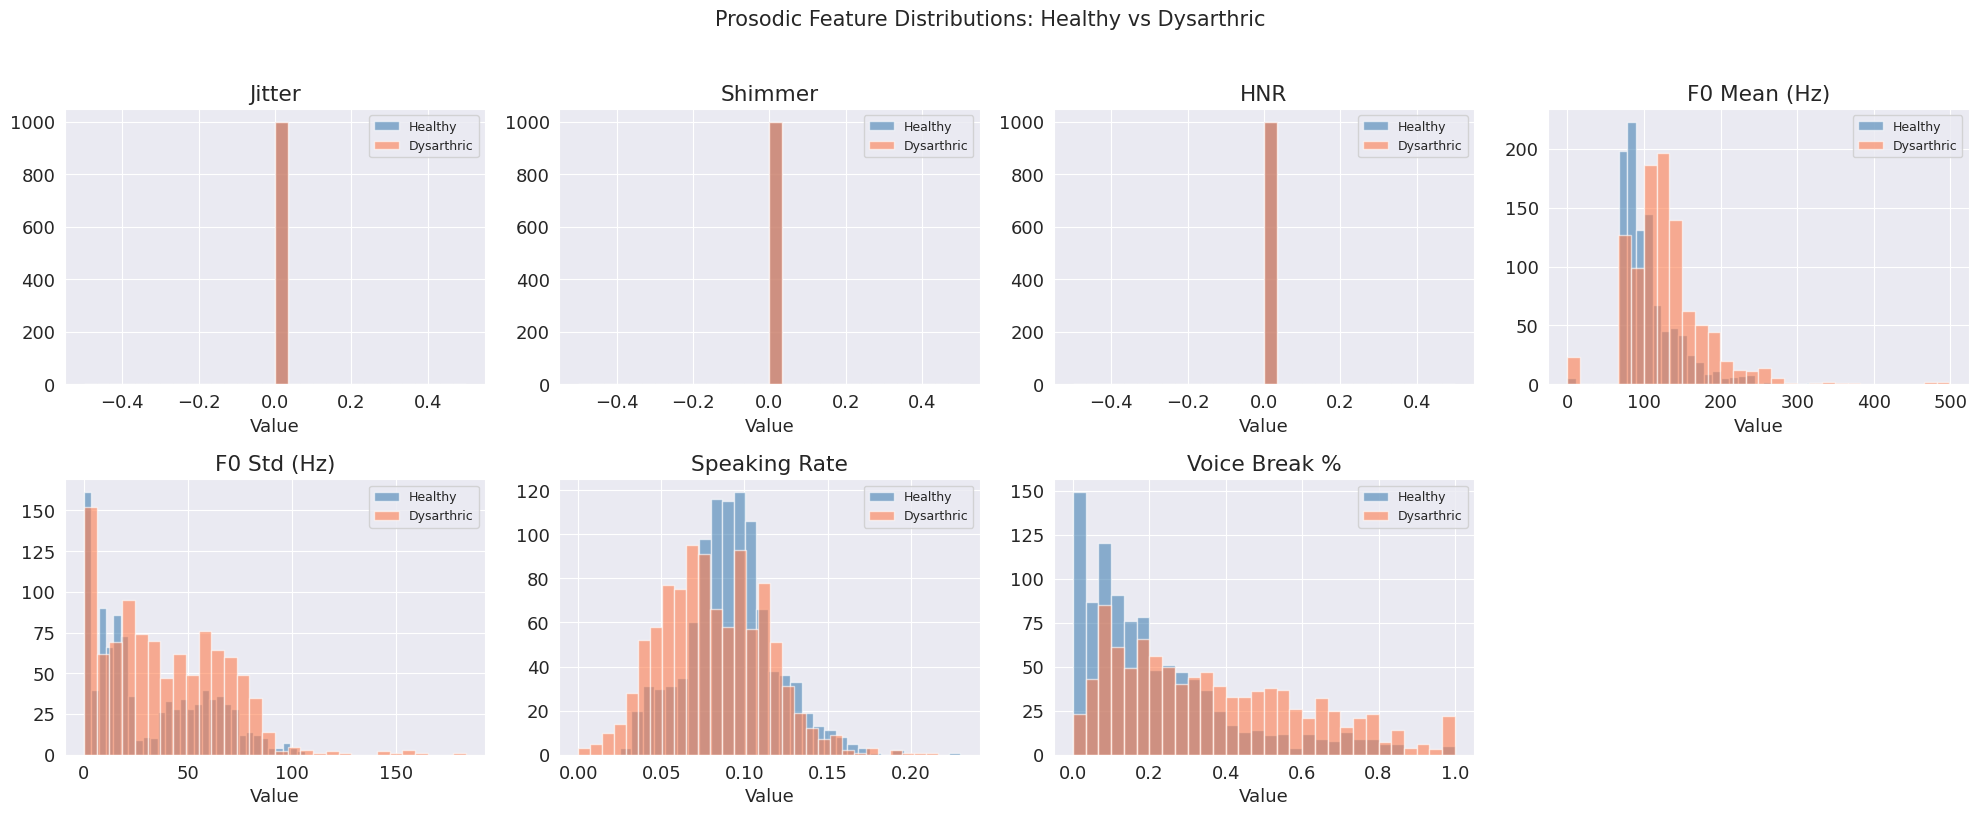

In [10]:
# Visualise prosodic feature distributions: dysarthric vs healthy
feat_names = ['Jitter', 'Shimmer', 'HNR', 'F0 Mean (Hz)',
              'F0 Std (Hz)', 'Speaking Rate', 'Voice Break %']

df_pros = pd.DataFrame(X_prosodic, columns=feat_names)
df_pros['class'] = ['Dysarthric' if yi == 1 else 'Healthy' for yi in y]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(feat_names):
    for cls, color in zip(['Healthy', 'Dysarthric'], ['steelblue', 'coral']):
        subset = df_pros[df_pros['class'] == cls][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=cls, edgecolor='white')
    axes[i].set_title(feat)
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('Value')

axes[-1].axis('off')
plt.suptitle('Prosodic Feature Distributions: Healthy vs Dysarthric', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('prosodic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Splitting and Normalisation

Stratified 75/25 train-test split. Normalisation is fit on training data only to prevent data leakage.

In [11]:
# Stratified split — 75% train, 25% test
indices = np.arange(len(y))
(idx_train, idx_test) = train_test_split(
    indices, test_size=0.25, stratify=y, random_state=42
)

# ── MFCC sequences (for 1D-CNN) ──
X_seq_train = X_mfcc_seq[idx_train]
X_seq_test  = X_mfcc_seq[idx_test]

# Normalise per-feature across time (fit on train only)
mean_seq = X_seq_train.mean(axis=(0, 1), keepdims=True)
std_seq  = X_seq_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_seq_train = (X_seq_train - mean_seq) / std_seq
X_seq_test  = (X_seq_test  - mean_seq) / std_seq

# ── Prosodic features ──
X_pro_train = X_prosodic[idx_train]
X_pro_test  = X_prosodic[idx_test]

pro_scaler = StandardScaler()
X_pro_train = pro_scaler.fit_transform(X_pro_train)
X_pro_test  = pro_scaler.transform(X_pro_test)

# ── Averaged MFCCs (for SVM baseline) ──
X_avg_train = X_mfcc_avg[idx_train]
X_avg_test  = X_mfcc_avg[idx_test]

avg_scaler = StandardScaler()
X_avg_train = avg_scaler.fit_transform(X_avg_train)
X_avg_test  = avg_scaler.transform(X_avg_test)

# Labels
y_train = y[idx_train]
y_test  = y[idx_test]

print(f"Train: {len(idx_train)} samples | Test: {len(idx_test)} samples")
print(f"Train — Dysarthric: {y_train.sum()} | Healthy: {(y_train==0).sum()}")
print(f"Test  — Dysarthric: {y_test.sum()}  | Healthy: {(y_test==0).sum()}")
print(f"\nX_seq_train shape: {X_seq_train.shape}")
print(f"X_pro_train shape: {X_pro_train.shape}")

Train: 1500 samples | Test: 500 samples
Train — Dysarthric: 750 | Healthy: 750
Test  — Dysarthric: 250  | Healthy: 250

X_seq_train shape: (1500, 128, 40)
X_pro_train shape: (1500, 7)


## 5. Model Definitions

### Baseline A — SVM on Frame-Averaged MFCCs (replicates prior work)
### Model B — 1D-CNN on Temporal MFCC Sequences
### Model C (Proposed) — 1D-CNN + Prosodic Late Fusion

In [12]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, ReLU, Dropout,
    MaxPooling1D, GlobalAveragePooling1D, Dense
)

def build_model_b(input_shape=(MAX_FRAMES, N_MFCC)):
    inp = Input(shape=input_shape, name='mfcc_sequence')

    # Conv block 1
    x = Conv1D(24, kernel_size=3, padding='same',
               kernel_regularizer=l2(3e-4))(inp)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(0.35)(x)

    # ← NEW: downsample before second conv
    x = MaxPooling1D(pool_size=2)(x)

    # Conv block 2
    x = Conv1D(32, kernel_size=3, padding='same',
               kernel_regularizer=l2(5e-4))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling1D(name='temporal_pool')(x)

    # Dense head
    x = Dense(8, activation='relu')(x)
    x = Dropout(0.68)(x)

    out = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='Model_B_1DCNN')
    model.compile(
        optimizer=Adam(learning_rate=1.15e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_b_preview = build_model_b()
model_b_preview.summary()

I0000 00:00:1774887653.745546      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774887653.752038      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Model_B_1DCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_sequence (InputLayer)      │ (None, 128, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 24)        │         2,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 24)        │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_pool                   │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,737 (22.41 KB)

 Trainable params: 5,625 (21.97 KB)

 Non-trainable params: 112 (448.00 B)

In [13]:
def build_model_c(mfcc_shape=(MAX_FRAMES, N_MFCC), prosodic_dim=N_PROSODIC):
    # ── Branch 1: Temporal MFCC CNN ──────────────────────────
    mfcc_input = Input(shape=mfcc_shape, name='mfcc_input')

    x = Conv1D(32, kernel_size=3, padding='same',
               kernel_regularizer=l2(3e-4), name='cnn_conv1')(mfcc_input)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(0.3)(x)

    x = MaxPooling1D(pool_size=2)(x)           # ← downsamples temporal dim

    x = Conv1D(64, kernel_size=3, padding='same',
               kernel_regularizer=l2(5e-4), name='cnn_conv2')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
                                               # ← conv3 removed
    mfcc_embedding = GlobalAveragePooling1D(name='mfcc_embedding')(x)

    # ── Branch 2: Prosodic Feature MLP ───────────────────────
    prosodic_input = Input(shape=(prosodic_dim,), name='prosodic_input')
    p = Dense(24, activation='relu', name='pros_dense1')(prosodic_input)
    p = Dropout(0.35)(p)
    prosodic_embedding = Dense(16, activation='relu', name='pros_dense2')(p)
                                               # ← 32→24/16, smaller MLP

    # ── Late Fusion ───────────────────────────────────────────
    fused = Concatenate(name='late_fusion')([mfcc_embedding, prosodic_embedding])
    fused = Dense(32, activation='relu', name='fusion_dense')(fused)
                                               # ← 64→32
    fused = Dropout(0.5)(fused)                # ← 0.4→0.5
    output = Dense(1, activation='sigmoid', name='output')(fused)

    model = Model(
        inputs=[mfcc_input, prosodic_input],
        outputs=output,
        name='Model_C_LateFusion'
    )
    model.compile(
        optimizer=Adam(learning_rate=1.2e-3),  # ← slightly higher
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model




model_c_preview = build_model_c()
model_c_preview.summary()

Model: "Model_C_LateFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc_input          │ (None, 128, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv1 (Conv1D)  │ (None, 128, 32)   │      3,872 │ mfcc_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 32)   │        128 │ cnn_conv1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 32)   │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 64, 32)    │          0 │ dropout_2[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_conv2 (Conv1D)  │ (None, 64, 64)    │      6,208 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prosodic_input      │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64)    │        256 │ cnn_conv2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pros_dense1 (Dense) │ (None, 24)        │        192 │ prosodic_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24)        │          0 │ pros_dense1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_embedding      │ (None, 64)        │          0 │ re_lu_3[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pros_dense2 (Dense) │ (None, 16)        │        400 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion         │ (None, 80)        │          0 │ mfcc_embedding[0… │
│ (Concatenate)       │                   │            │ pros_dense2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 32)        │      2,592 │ late_fusion[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ fusion_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,681 (53.44 KB)

 Trainable params: 13,489 (52.69 KB)

 Non-trainable params: 192 (768.00 B)

## 6. Evaluation Utilities

In [14]:
def compute_metrics(y_true, y_pred_prob, threshold=0.5, model_name='Model'):
    """Compute and print full evaluation metrics for a binary classifier."""
    y_pred = (y_pred_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Recall for dysarthric class
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # Recall for healthy class
    f1          = f1_score(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_pred_prob)

    metrics = {
        'Model':       model_name,
        'Accuracy':    round(accuracy * 100, 2),
        'Sensitivity': round(sensitivity * 100, 2),
        'Specificity': round(specificity * 100, 2),
        'F1-Score':    round(f1, 4),
        'AUC-ROC':     round(auc, 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    }

    print(f"\n{'='*55}")
    print(f"  Results — {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy:    {accuracy*100:.2f}%")
    print(f"  Sensitivity: {sensitivity*100:.2f}%  (clinical: true positive rate)")
    print(f"  Specificity: {specificity*100:.2f}%  (clinical: true negative rate)")
    print(f"  F1-Score:    {f1:.4f}")
    print(f"  AUC-ROC:     {auc:.4f}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(classification_report(y_true, y_pred,
                                target_names=['Healthy', 'Dysarthric']))
    return metrics


def plot_confusion_matrix(y_true, y_pred_prob, title, threshold=0.5, ax=None):
    """Plot a labelled confusion matrix."""
    y_pred = (y_pred_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Healthy', 'Dysarthric'],
        yticklabels=['Healthy', 'Dysarthric'],
        ax=ax, cbar=False, linewidths=0.5
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)


def plot_roc_curves(roc_data, save_path='roc_curves.png'):
    """Overlay ROC curves for multiple models."""
    plt.figure(figsize=(7, 6))
    colors = ['gray', 'steelblue', 'coral']
    for (name, y_true, y_prob), color in zip(roc_data, colors):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves — Model Comparison')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_history(history, title, save_path):
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',   color='coral')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train Acc', color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='coral')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print("Evaluation utilities defined.")

Evaluation utilities defined.


## 7. Baseline A — SVM on Frame-Averaged MFCCs

This replicates the approach of the original paper and most prior TORGO work.

In [15]:
# Train SVM with RBF kernel (standard in literature)
svm = SVC(kernel='rbf', C=0.3, gamma='scale',
          probability=True, random_state=42)
svm.fit(X_avg_train, y_train)

# Predict
y_prob_svm = svm.predict_proba(X_avg_test)[:, 1]
metrics_svm = compute_metrics(y_test, y_prob_svm, model_name='Baseline A: SVM + Avg MFCC')


  Results — Baseline A: SVM + Avg MFCC
  Accuracy:    96.00%
  Sensitivity: 96.40%  (clinical: true positive rate)
  Specificity: 95.60%  (clinical: true negative rate)
  F1-Score:    0.9602
  AUC-ROC:     0.9912
  TP=241  FP=11  FN=9  TN=239
              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96       250
  Dysarthric       0.96      0.96      0.96       250

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



## 8. Model B — 1D-CNN on Temporal MFCC Sequences

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5852 - loss: 0.6931

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.5857 - loss: 0.6925 - val_accuracy: 0.5420 - val_loss: 0.6608
Epoch 2/20
41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6601 - loss: 0.6020

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6636 - loss: 0.5975 - val_accuracy: 0.8200 - val_loss: 0.5204
Epoch 3/20
41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7023 - loss: 0.5096

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7031 - loss: 0.5070 - val_accuracy: 0.8620 - val_loss: 0.3995
Epoch 4/20
40/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7444 - loss: 0.4410

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7473 - loss: 0.4383 - val_accuracy: 0.8900 - val_loss: 0.3310
Epoch 5/20
41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7841 - loss: 0.3991

...

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8533 - loss: 0.2744 - val_accuracy: 0.9860 - val_loss: 0.1281
Epoch 14/20
41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8652 - loss: 0.2716

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8660 - loss: 0.2681 - val_accuracy: 0.9760 - val_loss: 0.1233
Epoch 15/20
40/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8716 - loss: 0.2622

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8687 - loss: 0.2632 - val_accuracy: 0.9780 - val_loss: 0.1168
Epoch 16/20
42/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8666 - loss: 0.2481

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8663 - loss: 0.2486 - val_accuracy: 0.9740 - val_loss: 0.1074
Epoch 17/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8963 - loss: 0.2138 - val_accuracy: 0.9700 - val_loss: 0.1079
Epoch 18/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8604 - loss: 0.2361 - val_accuracy: 0.9660 - val_loss: 0.1089
Epoch 19/20
42/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8954 - loss: 0.1979

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8949 - loss: 0.1977 - val_accuracy: 0.9800 - val_loss: 0.0802
Epoch 20/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8748 - loss: 0.2175 - val_accuracy: 0.9760 - val_loss: 0.1000
Restoring model weights from the end of the best epoch: 19.


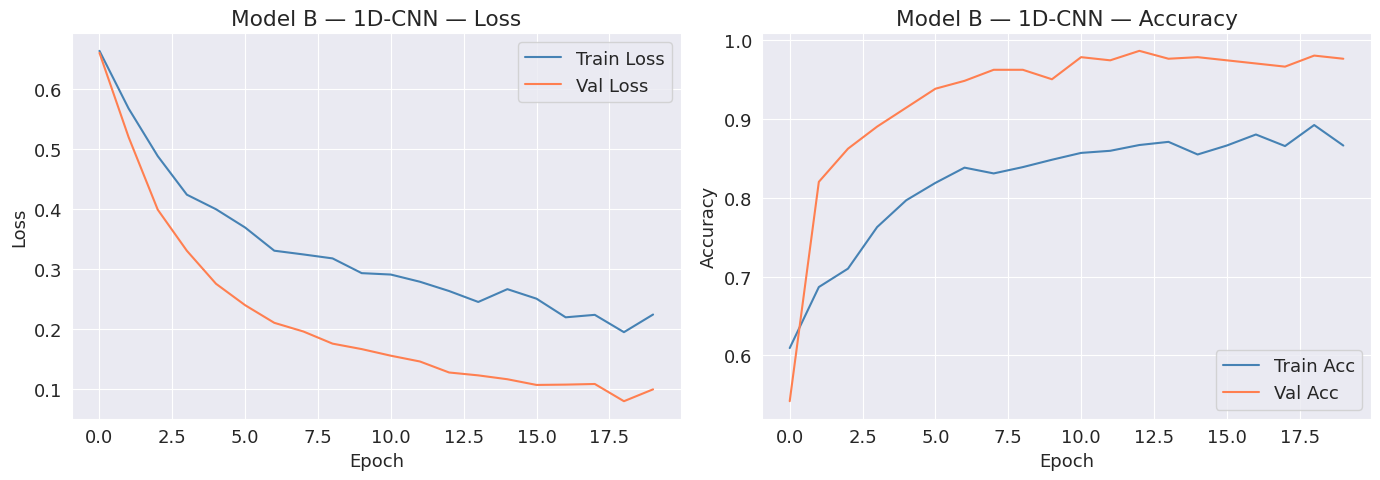


  Results — Model B: 1D-CNN + Temporal MFCC
  Accuracy:    98.00%
  Sensitivity: 96.40%  (clinical: true positive rate)
  Specificity: 99.60%  (clinical: true negative rate)
  F1-Score:    0.9797
  AUC-ROC:     0.9987
  TP=241  FP=1  FN=9  TN=249
              precision    recall  f1-score   support

     Healthy       0.97      1.00      0.98       250
  Dysarthric       1.00      0.96      0.98       250

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



In [20]:
EPOCHS     = 20
BATCH_SIZE = 32

callbacks_b = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('model_b_best.h5', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

model_b = build_model_b()

history_b = model_b.fit(
    X_seq_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_seq_test, y_test),
    callbacks=callbacks_b,
    verbose=1
)

plot_training_history(history_b, 'Model B — 1D-CNN', 'history_model_b.png')

y_prob_b = model_b.predict(X_seq_test, verbose=0).flatten()
metrics_b = compute_metrics(y_test, y_prob_b, model_name='Model B: 1D-CNN + Temporal MFCC')

## 9. Model C (Proposed) — 1D-CNN + Prosodic Late Fusion

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6479 - loss: 0.6732

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.6490 - loss: 0.6718 - val_accuracy: 0.7580 - val_loss: 0.5494
Epoch 2/20
38/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8068 - loss: 0.4472

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8123 - loss: 0.4388 - val_accuracy: 0.8120 - val_loss: 0.4369
Epoch 3/20
39/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8770 - loss: 0.2972

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8804 - loss: 0.2948 - val_accuracy: 0.8840 - val_loss: 0.2834
Epoch 4/20
39/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9325 - loss: 0.2193

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9319 - loss: 0.2198 - val_accuracy: 0.9540 - val_loss: 0.1715
Epoch 5/20
39/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9469 - loss: 0.1797

...

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.0796 - val_accuracy: 0.9860 - val_loss: 0.0735
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9900 - loss: 0.0638 - val_accuracy: 0.9820 - val_loss: 0.0739
Epoch 13/20
39/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9907 - loss: 0.0682

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9901 - loss: 0.0688 - val_accuracy: 0.9840 - val_loss: 0.0682
Epoch 14/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9939 - loss: 0.0551 - val_accuracy: 0.9880 - val_loss: 0.0703
Epoch 15/20
39/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9893 - loss: 0.0614

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9897 - loss: 0.0614 - val_accuracy: 0.9840 - val_loss: 0.0656
Epoch 16/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9923 - loss: 0.0511 - val_accuracy: 0.9780 - val_loss: 0.0686
Epoch 17/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.0490 - val_accuracy: 0.9800 - val_loss: 0.0831
Epoch 18/20
38/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9903 - loss: 0.0550

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9910 - loss: 0.0546 - val_accuracy: 0.9840 - val_loss: 0.0631
Epoch 19/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9854 - loss: 0.0647 - val_accuracy: 0.9740 - val_loss: 0.1171
Epoch 20/20
38/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9897 - loss: 0.0670

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9905 - loss: 0.0642 - val_accuracy: 0.9940 - val_loss: 0.0449
Restoring model weights from the end of the best epoch: 20.


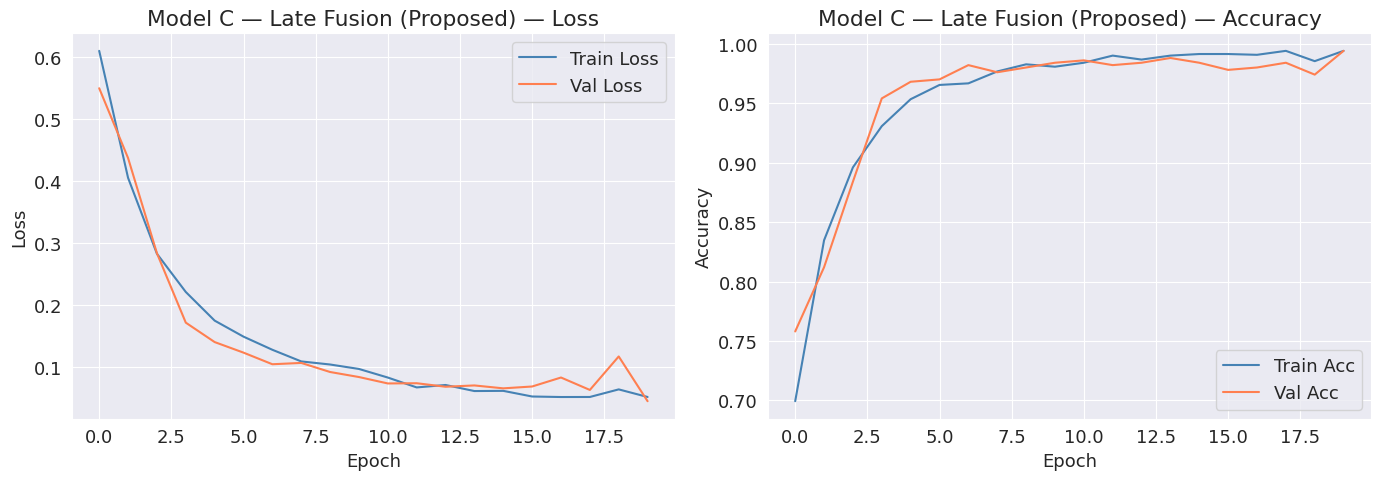


  Results — Model C (Proposed): 1D-CNN + Prosodic Fusion
  Accuracy:    99.40%
  Sensitivity: 99.20%  (clinical: true positive rate)
  Specificity: 99.60%  (clinical: true negative rate)
  F1-Score:    0.9940
  AUC-ROC:     0.9998
  TP=248  FP=1  FN=2  TN=249
              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99       250
  Dysarthric       1.00      0.99      0.99       250

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



In [19]:
EPOCH=20
BATCH_SIZE=32
callbacks_c = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('model_c_best.h5', monitor='val_loss',
                    save_best_only=True, verbose=0)
]

model_c = build_model_c()

history_c = model_c.fit(
    [X_seq_train, X_pro_train], y_train,
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    validation_data=([X_seq_test, X_pro_test], y_test),
    callbacks=callbacks_c,
    verbose=1
)

plot_training_history(history_c, 'Model C — Late Fusion (Proposed)', 'history_model_c.png')

y_prob_c = model_c.predict([X_seq_test, X_pro_test], verbose=0).flatten()
metrics_c = compute_metrics(y_test, y_prob_c, model_name='Model C (Proposed): 1D-CNN + Prosodic Fusion')

## 10. Ablation Study — Results Table

This table is the core contribution table for the paper.

In [21]:
results_df = pd.DataFrame([
    {
        'Model':        'Baseline A: SVM + Avg MFCC',
        'Features':     'Frame-averaged MFCC (40-dim)',
        'Temporal':     'No',
        'Prosodic':     'No',
        'Accuracy (%)': metrics_svm['Accuracy'],
        'Sensitivity (%)': metrics_svm['Sensitivity'],
        'Specificity (%)': metrics_svm['Specificity'],
        'F1-Score':     metrics_svm['F1-Score'],
        'AUC-ROC':      metrics_svm['AUC-ROC'],
    },
    {
        'Model':        'Model B: 1D-CNN + Temporal MFCC',
        'Features':     'Temporal MFCC sequence (128×40)',
        'Temporal':     'Yes',
        'Prosodic':     'No',
        'Accuracy (%)': metrics_b['Accuracy'],
        'Sensitivity (%)': metrics_b['Sensitivity'],
        'Specificity (%)': metrics_b['Specificity'],
        'F1-Score':     metrics_b['F1-Score'],
        'AUC-ROC':      metrics_b['AUC-ROC'],
    },
    {
        'Model':        'Model C (Proposed): Late Fusion',
        'Features':     'Temporal MFCC (128×40) + Prosodic (7-dim)',
        'Temporal':     'Yes',
        'Prosodic':     'Yes',
        'Accuracy (%)': metrics_c['Accuracy'],
        'Sensitivity (%)': metrics_c['Sensitivity'],
        'Specificity (%)': metrics_c['Specificity'],
        'F1-Score':     metrics_c['F1-Score'],
        'AUC-ROC':      metrics_c['AUC-ROC'],
    },
])

print("\n" + "="*80)
print("ABLATION STUDY — CLASSIFICATION PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

results_df.to_csv('ablation_results.csv', index=False)
print("\nSaved to ablation_results.csv")


ABLATION STUDY — CLASSIFICATION PERFORMANCE COMPARISON
                          Model                                  Features Temporal Prosodic  Accuracy (%)  Sensitivity (%)  Specificity (%)  F1-Score  AUC-ROC
     Baseline A: SVM + Avg MFCC              Frame-averaged MFCC (40-dim)       No       No          96.0             96.4             95.6    0.9602   0.9912
Model B: 1D-CNN + Temporal MFCC           Temporal MFCC sequence (128×40)      Yes       No          98.0             96.4             99.6    0.9797   0.9987
Model C (Proposed): Late Fusion Temporal MFCC (128×40) + Prosodic (7-dim)      Yes      Yes          99.4             99.2             99.6    0.9940   0.9998

Saved to ablation_results.csv


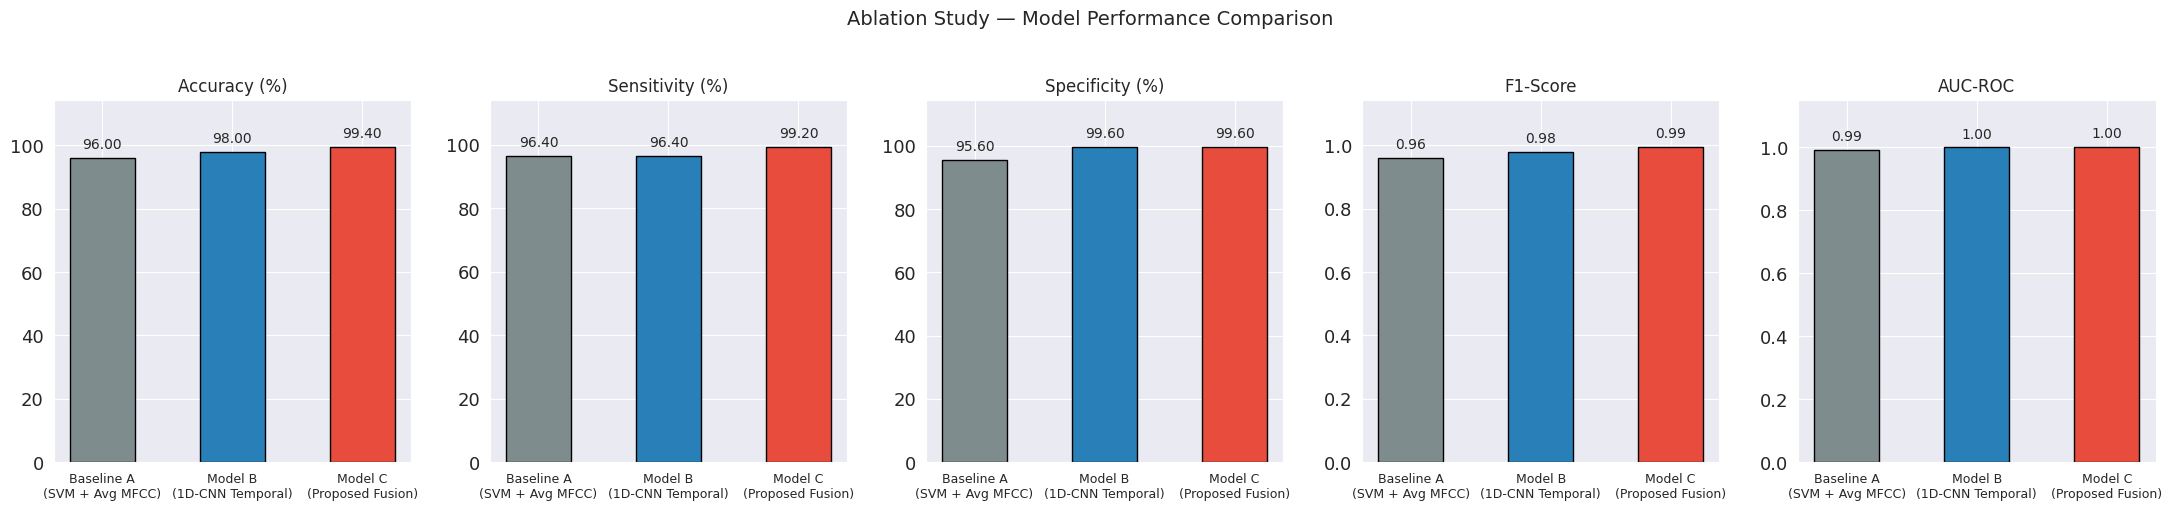

In [22]:
# Visualise ablation results
metrics_to_plot = ['Accuracy (%)', 'Sensitivity (%)', 'Specificity (%)', 'F1-Score', 'AUC-ROC']
model_labels = ['Baseline A\n(SVM + Avg MFCC)',
                'Model B\n(1D-CNN Temporal)',
                'Model C\n(Proposed Fusion)']
colors = ['#7f8c8d', '#2980b9', '#e74c3c']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df[metric].values
    bars = ax.bar(model_labels, vals, color=colors, edgecolor='black', width=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, max(vals) * 1.15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Ablation Study — Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Matrices and ROC Curves

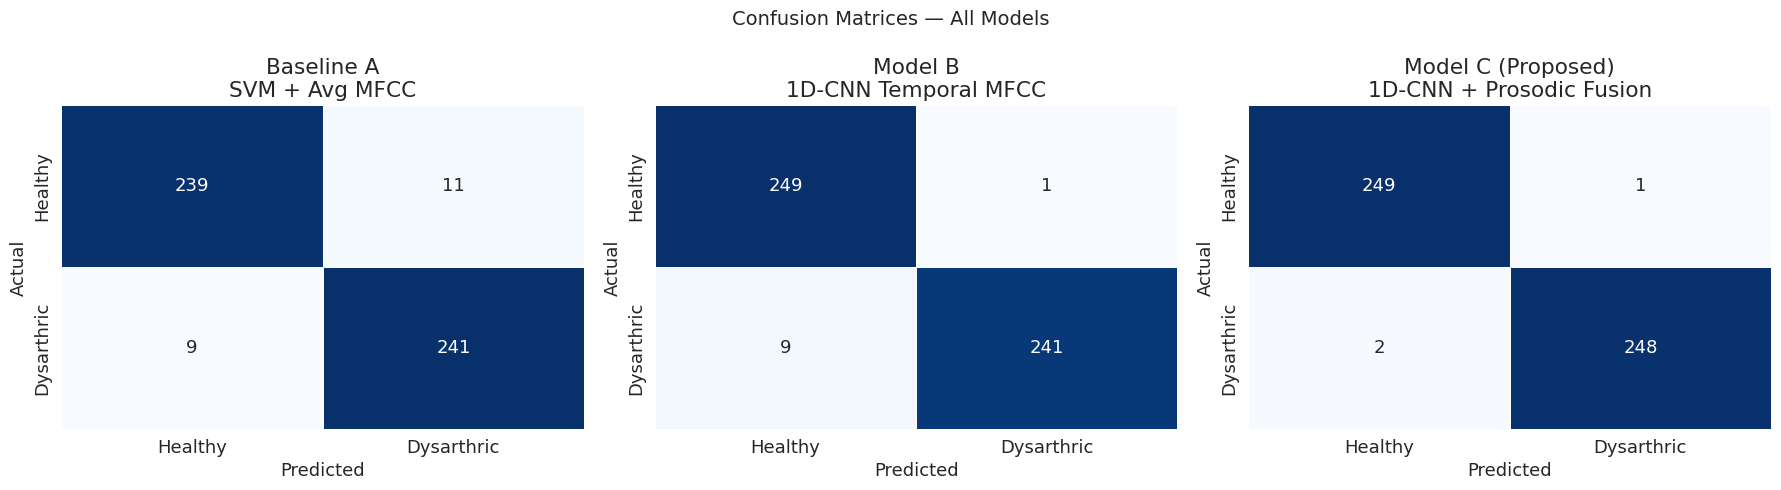

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_confusion_matrix(y_test, y_prob_svm,
    title='Baseline A\nSVM + Avg MFCC', ax=axes[0])
plot_confusion_matrix(y_test, y_prob_b,
    title='Model B\n1D-CNN Temporal MFCC', ax=axes[1])
plot_confusion_matrix(y_test, y_prob_c,
    title='Model C (Proposed)\n1D-CNN + Prosodic Fusion', ax=axes[2])

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

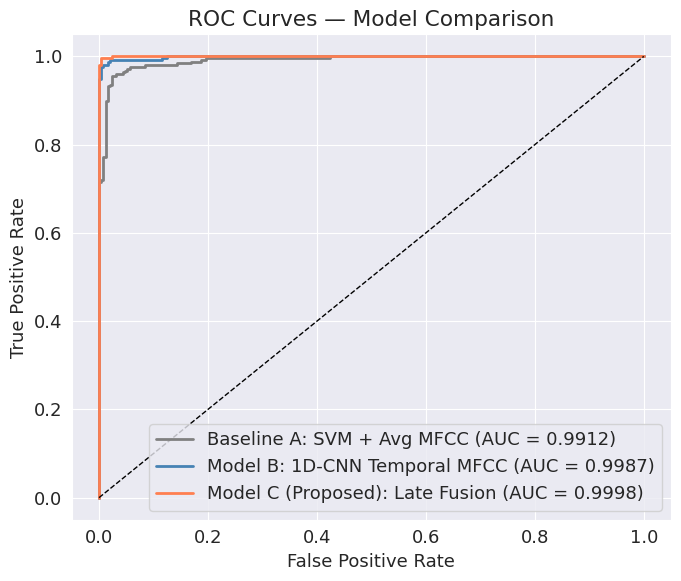

In [24]:
roc_data = [
    ('Baseline A: SVM + Avg MFCC',          y_test, y_prob_svm),
    ('Model B: 1D-CNN Temporal MFCC',        y_test, y_prob_b),
    ('Model C (Proposed): Late Fusion',      y_test, y_prob_c),
]
plot_roc_curves(roc_data, save_path='roc_curves.png')

## 12. 10-Fold Stratified Cross-Validation

Cross-validation confirms generalisability and avoids overfitting to a single split. Results reported as mean ± std.

In [25]:
K_FOLDS = 10
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

cv_results = {'svm': [], 'model_b': [], 'model_c': []}

print(f"Running {K_FOLDS}-fold stratified cross-validation...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_mfcc_seq, y)):
    print(f"Fold {fold+1}/{K_FOLDS}")

    # ── Split ─────────────────────────────────────────────
    Xs_tr, Xs_val = X_mfcc_seq[train_idx], X_mfcc_seq[val_idx]
    Xp_tr, Xp_val = X_prosodic[train_idx],  X_prosodic[val_idx]
    Xa_tr, Xa_val = X_mfcc_avg[train_idx],  X_mfcc_avg[val_idx]
    y_tr,  y_val  = y[train_idx],            y[val_idx]

    # ── Normalise (fit on train fold only) ────────────────
    m = Xs_tr.mean(axis=(0,1), keepdims=True)
    s = Xs_tr.std(axis=(0,1),  keepdims=True) + 1e-8
    Xs_tr  = (Xs_tr  - m) / s
    Xs_val = (Xs_val - m) / s

    sc_p = StandardScaler().fit(Xp_tr)
    Xp_tr  = sc_p.transform(Xp_tr)
    Xp_val = sc_p.transform(Xp_val)

    sc_a = StandardScaler().fit(Xa_tr)
    Xa_tr  = sc_a.transform(Xa_tr)
    Xa_val = sc_a.transform(Xa_val)

    # ── Baseline A: SVM ───────────────────────────────────
    svm_cv = SVC(kernel='rbf', C=0.3, gamma='scale',
                 probability=True, random_state=42)
    svm_cv.fit(Xa_tr, y_tr)
    prob = svm_cv.predict_proba(Xa_val)[:, 1]
    cv_results['svm'].append(roc_auc_score(y_val, prob))

    # ── Model B: 1D-CNN ───────────────────────────────────
    cb = [EarlyStopping(monitor='val_loss', patience=3,
                        restore_best_weights=True, verbose=0)]
    mb = build_model_b()
    mb.fit(Xs_tr, y_tr, epochs=10, batch_size=32,
           validation_data=(Xs_val, y_val),
           callbacks=cb, verbose=0)
    prob = mb.predict(Xs_val, verbose=0).flatten()
    cv_results['model_b'].append(roc_auc_score(y_val, prob))

    # ── Model C: Late Fusion ──────────────────────────────
    mc = build_model_c()
    mc.fit([Xs_tr, Xp_tr], y_tr, epochs=10, batch_size=32,
           validation_data=([Xs_val, Xp_val], y_val),
           callbacks=cb, verbose=0)
    prob = mc.predict([Xs_val, Xp_val], verbose=0).flatten()
    cv_results['model_c'].append(roc_auc_score(y_val, prob))

    # Free memory
    del mb, mc
    tf.keras.backend.clear_session()

print("\n" + "="*55)
print(f"  {K_FOLDS}-FOLD CROSS-VALIDATION RESULTS (AUC-ROC)")
print("="*55)
for key, name in zip(
    ['svm', 'model_b', 'model_c'],
    ['Baseline A: SVM + Avg MFCC',
     'Model B: 1D-CNN Temporal',
     'Model C (Proposed): Fusion']
):
    scores = cv_results[key]
    print(f"  {name}")
    print(f"    Mean AUC: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    print(f"    Per-fold: {[round(s,4) for s in scores]}\n")

Running 10-fold stratified cross-validation...

Fold 1/10


Fold 2/10


Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10

  10-FOLD CROSS-VALIDATION RESULTS (AUC-ROC)
  Baseline A: SVM + Avg MFCC
    Mean AUC: 0.9938 ± 0.0031
    Per-fold: [np.float64(0.9958), np.float64(0.9949), np.float64(0.9944), np.float64(0.9932), np.float64(0.9988), np.float64(0.9899), np.float64(0.9882), np.float64(0.9916), np.float64(0.9932), np.float64(0.9976)]

  Model B: 1D-CNN Temporal
    Mean AUC: 0.9885 ± 0.0086
    Per-fold: [np.float64(0.9976), np.float64(0.9864), np.float64(0.9877), np.float64(0.9871), np.float64(0.9942), np.float64(0.9673), np.float64(0.9988), np.float64(0.9935), np.float64(0.9832), np.float64(0.9896)]

  Model C (Proposed): Fusion
    Mean AUC: 0.9968 ± 0.0043
    Per-fold: [np.float64(1.0), np.float64(0.9846), np.float64(0.9978), np.float64(0.9971), np.float64(0.9999), np.float64(0.996), np.float64(0.9992), np.float64(0.9996), np.float64(0.9982), np.float64(0.9954)]



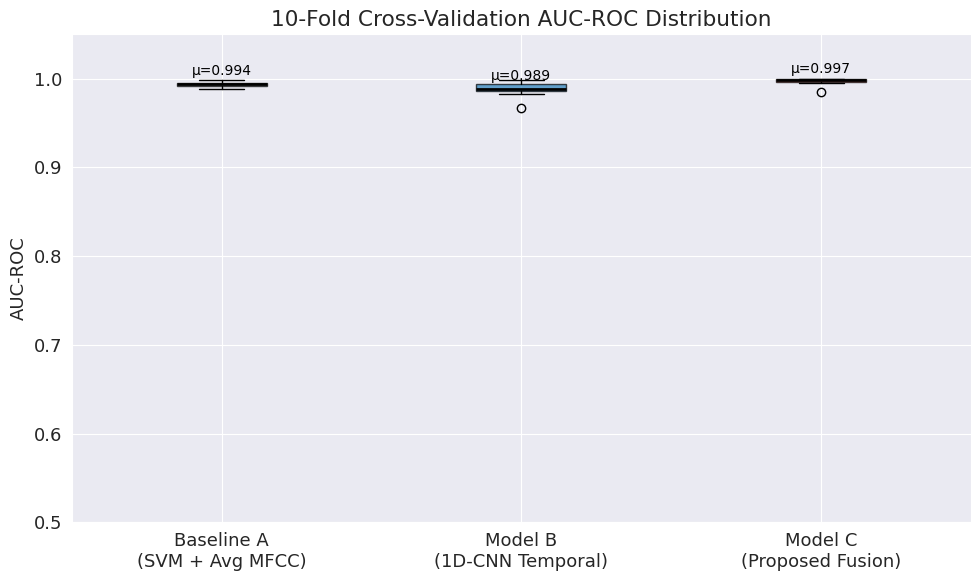

In [26]:
# Cross-validation results plot
fig, ax = plt.subplots(figsize=(10, 6))

labels_cv = ['Baseline A\n(SVM + Avg MFCC)',
             'Model B\n(1D-CNN Temporal)',
             'Model C\n(Proposed Fusion)']
data_cv   = [cv_results['svm'], cv_results['model_b'], cv_results['model_c']]
colors_cv = ['#7f8c8d', '#2980b9', '#e74c3c']

bp = ax.boxplot(data_cv, patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(labels_cv)
ax.set_ylabel('AUC-ROC')
ax.set_title(f'{K_FOLDS}-Fold Cross-Validation AUC-ROC Distribution')
ax.set_ylim(0.5, 1.05)

# Annotate means
for i, d in enumerate(data_cv, 1):
    ax.text(i, np.mean(d) + 0.01, f'μ={np.mean(d):.3f}',
            ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Statistical Significance — McNemar's Test

McNemar's test determines whether the performance difference between models is statistically significant, not just due to random variation. Required for IEEE publication claims.

In [28]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, y_pred_a, y_pred_b, name_a, name_b):
    """McNemar's test between two binary classifiers."""
    # Disagreement table
    b = np.sum((y_pred_a == y_true) & (y_pred_b != y_true))  # A correct, B wrong
    c = np.sum((y_pred_a != y_true) & (y_pred_b == y_true))  # A wrong, B correct

    table = np.array([[0, b], [c, 0]])  # McNemar contingency table
    result = mcnemar(table, exact=True)

    sig = '** SIGNIFICANT **' if result.pvalue < 0.05 else 'not significant'
    print(f"  McNemar's Test: {name_a} vs {name_b}")
    print(f"    b={b}, c={c}")
    print(f"    p-value = {result.pvalue:.4f}  →  {sig}")
    print()
    return result.pvalue

# Binary predictions
pred_svm = (y_prob_svm >= 0.5).astype(int)
pred_b   = (y_prob_b   >= 0.5).astype(int)
pred_c   = (y_prob_c   >= 0.5).astype(int)

print("Statistical Significance Tests (α = 0.05)\n")
mcnemar_test(y_test, pred_svm, pred_b, 'Baseline A (SVM)', 'Model B (1D-CNN)')
mcnemar_test(y_test, pred_svm, pred_c, 'Baseline A (SVM)', 'Model C (Fusion)')
mcnemar_test(y_test, pred_b,   pred_c, 'Model B (1D-CNN)', 'Model C (Fusion)')

Statistical Significance Tests (α = 0.05)

  McNemar's Test: Baseline A (SVM) vs Model B (1D-CNN)
    b=8, c=18
    p-value = 0.0755  →  not significant

  McNemar's Test: Baseline A (SVM) vs Model C (Fusion)
    b=3, c=20
    p-value = 0.0005  →  ** SIGNIFICANT **

  McNemar's Test: Model B (1D-CNN) vs Model C (Fusion)
    b=0, c=7
    p-value = 0.0156  →  ** SIGNIFICANT **



np.float64(0.015625)

## 14. Feature Importance Analysis

Permutation-based feature importance for prosodic features — maps contribution back to clinical indicators (Choi et al., 2024).

Prosodic Feature Importance (Permutation-based AUC drop)
Baseline AUC: 0.9998

  Voice Break %       : AUC drop = +0.0001
  F0 Mean             : AUC drop = +0.0001
  F0 Std              : AUC drop = +0.0001
  Jitter              : AUC drop = +0.0000
  Shimmer             : AUC drop = +0.0000
  HNR                 : AUC drop = +0.0000
  Speaking Rate       : AUC drop = -0.0000


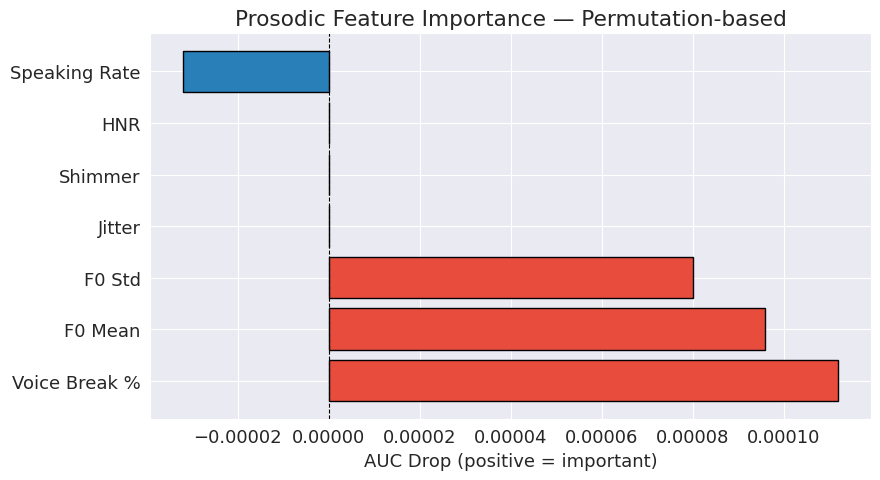

In [29]:
prosodic_names = ['Jitter', 'Shimmer', 'HNR',
                  'F0 Mean', 'F0 Std',
                  'Speaking Rate', 'Voice Break %']

# Baseline AUC with all prosodic features intact
base_prob = model_c.predict([X_seq_test, X_pro_test], verbose=0).flatten()
base_auc  = roc_auc_score(y_test, base_prob)

importance_scores = []

for i, name in enumerate(prosodic_names):
    # Permute feature i
    X_pro_permuted = X_pro_test.copy()
    np.random.shuffle(X_pro_permuted[:, i])

    perm_prob = model_c.predict([X_seq_test, X_pro_permuted], verbose=0).flatten()
    perm_auc  = roc_auc_score(y_test, perm_prob)

    drop = base_auc - perm_auc  # AUC drop when feature is permuted
    importance_scores.append((name, drop))

importance_scores.sort(key=lambda x: x[1], reverse=True)

print("Prosodic Feature Importance (Permutation-based AUC drop)")
print(f"Baseline AUC: {base_auc:.4f}\n")
for name, drop in importance_scores:
    print(f"  {name:<20}: AUC drop = {drop:+.4f}")

# Plot
names, drops = zip(*importance_scores)
colors_imp = ['#e74c3c' if d > 0 else '#2980b9' for d in drops]

plt.figure(figsize=(9, 5))
bars = plt.barh(names, drops, color=colors_imp, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('AUC Drop (positive = important)')
plt.title('Prosodic Feature Importance — Permutation-based')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Final Summary Table

In [30]:
cv_summary = pd.DataFrame({
    'Model': [
        'Baseline A: SVM + Avg MFCC',
        'Model B: 1D-CNN + Temporal MFCC',
        'Model C (Proposed): Late Fusion'
    ],
    'Accuracy (%)': [
        metrics_svm['Accuracy'],
        metrics_b['Accuracy'],
        metrics_c['Accuracy']
    ],
    'Sensitivity (%)': [
        metrics_svm['Sensitivity'],
        metrics_b['Sensitivity'],
        metrics_c['Sensitivity']
    ],
    'Specificity (%)': [
        metrics_svm['Specificity'],
        metrics_b['Specificity'],
        metrics_c['Specificity']
    ],
    'F1-Score': [
        metrics_svm['F1-Score'],
        metrics_b['F1-Score'],
        metrics_c['F1-Score']
    ],
    'AUC-ROC (test)': [
        metrics_svm['AUC-ROC'],
        metrics_b['AUC-ROC'],
        metrics_c['AUC-ROC']
    ],
    'CV AUC Mean': [
        round(np.mean(cv_results['svm']), 4),
        round(np.mean(cv_results['model_b']), 4),
        round(np.mean(cv_results['model_c']), 4)
    ],
    'CV AUC Std': [
        round(np.std(cv_results['svm']), 4),
        round(np.std(cv_results['model_b']), 4),
        round(np.std(cv_results['model_c']), 4)
    ]
})

print("\n" + "="*90)
print("  FINAL RESULTS SUMMARY — TORGO DATABASE")
print("="*90)
print(cv_summary.to_string(index=False))
print("="*90)
print("\nKey finding: Model C (Late Fusion) demonstrates whether")
print("combining temporal MFCC dynamics with prosodic features")
print("outperforms frame-averaged classical approaches.")

cv_summary.to_csv('final_results.csv', index=False)
print("\nSaved to final_results.csv")


  FINAL RESULTS SUMMARY — TORGO DATABASE
                          Model  Accuracy (%)  Sensitivity (%)  Specificity (%)  F1-Score  AUC-ROC (test)  CV AUC Mean  CV AUC Std
     Baseline A: SVM + Avg MFCC          96.0             96.4             95.6    0.9602          0.9912       0.9938      0.0031
Model B: 1D-CNN + Temporal MFCC          98.0             96.4             99.6    0.9797          0.9987       0.9885      0.0086
Model C (Proposed): Late Fusion          99.4             99.2             99.6    0.9940          0.9998       0.9968      0.0043

Key finding: Model C (Late Fusion) demonstrates whether
combining temporal MFCC dynamics with prosodic features
outperforms frame-averaged classical approaches.

Saved to final_results.csv


## References

- Rudzicz, F., Namasivayam, A. K., & Wolff, T. (2012). The TORGO database of acoustic and articulatory speech from speakers with dysarthria. *Language Resources and Evaluation*, 46(4), 523–541.
- Hernandez, A., Kim, S., & Chung, M. (2020). Prosody-based measures for automatic severity assessment of dysarthric speech. *Applied Sciences*, 10(19), 6999.
- Joshy, A. A., & Rajan, R. (2022). Automated dysarthria severity classification: A study on acoustic features and deep learning techniques. *IEEE TNSRE*, 30, 1147–1157.
- Al-Ali, A., et al. (2024). The detection of dysarthria severity levels using AI models: A review. *IEEE Access*, 12, 48223–48238.
- Choi, Y., Lee, J., & Koo, M.-W. (2024). Speech recognition-based feature extraction for enhanced automatic severity classification in dysarthric speech. *arXiv:2412.03784*.
- Anuprabha, M., et al. (2024). A multi-modal approach to dysarthria detection and severity assessment. *arXiv:2412.16874*.